In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Loading the dataset and displaying the first few rows and columns
beans = pd.read_excel('Dry_Bean_Dataset.xlsx')
beans.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
#Cleaning/Preprocessing the data

In [4]:
#Defining the shape of our dataset
beans.shape

(13611, 17)

In [5]:
#Getting the basic information about the dataset
beans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [6]:
#Check for any missing values
beans.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [7]:
#No missing values detected.

In [8]:
#Check the class distribution, to detect any imbalance between classes
beans['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [9]:
#We can see a strong imbalance between the "BOMBAY" type and the other types.

In [10]:
#Now we will convert the labels to numeric, since neural networks can't use strings

classes = sorted(beans['Class'].unique())
class_to_int = {c: i for i, c in enumerate(classes)}

y = beans['Class'].map(class_to_int).values
X = beans.drop('Class', axis=1).values

print(class_to_int)
print(X.shape, y.shape)

{'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}
(13611, 16) (13611,)


In [11]:
#Next step for the preprocessing is to use stratified sampling.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify=y,             #using stratified sampling
    random_state=42,        #we set a random state at 42, so we get the same split every time    
)

print(X_train.shape, X_test.shape)

(10888, 16) (2723, 16)


In [12]:
#Now we will perform feature scaling, because neural networks are sensitive to scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaled training mean:", X_train.mean())
print("Scaled training std:", X_train.std())

Scaled training mean: 7.311915788330881e-14
Scaled training std: 0.9999999999999997


In [13]:
#Now we create the Multilayer Perceptron skeleton

In [14]:
#Starting with the network dimensions

n_input = X_train.shape[1]
n_hidden = 128
n_output = len(np.unique(y_train))

#So we created an n_input for the 16 features, we created n_hidden neurons
#which are 20 but we will vary later and created n_output for the 7 classes

#Now we proceed to the random weight initialisation

np.random.seed(42)
W1 = np.random.randn(n_input, n_hidden)*np.sqrt(1/n_input)
b1 = np.zeros((1, n_hidden))

W2 = np.random.randn(n_hidden, n_output)*np.sqrt(1/n_hidden)
b2 = np.zeros((1, n_output))

#Now we create the activation functions

def sigmoid(z):
    return 1/(1+np.exp(-z))

def softmax(z):
    z = z-np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z/np.sum(exp_z, axis=1, keepdims=True)

#Now we proceed with the forward propagation. We will use just the sigmoid.

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1, a1, z2, a2

In [15]:
#We will do a quick check to see if everything is fine

z1, a1, z2, a2 = forward(X_train[:5], W1, b1, W2, b2)

print("Shape of hidden layer:", a1.shape)
print("The output of the shape:", a2.shape)
print("Probabilities sum to:", a2.sum(axis=1))

Shape of hidden layer: (5, 128)
The output of the shape: (5, 7)
Probabilities sum to: [3.64516088 3.52309317 3.55799849 3.61106931 3.62453314]


In [16]:
#Now we will do the one-hot endocing labels which are needed for multiclass loss
#ChatGPT prompt: Help me do one-hot encode labels

#Using the np.eye function

Y_train = np.eye(n_output)[y_train]
Y_test = np.eye(n_output)[y_test]

print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)


Y_train shape: (10888, 7)
Y_test shape: (2723, 7)


In [17]:
#Now we will proceed to the backpropagation

def init_parameters(n_hidden):
    W1=np.random.normal(0, 1, size=(n_input, n_hidden))*np.sqrt(1/n_input)
    b1=np.zeros((1, n_hidden))
    W2=np.random.normal(0, 1, size=(n_hidden, n_output))*np.sqrt(1/n_hidden)
    b2=np.zeros((1, n_output))
    return W1, b1, W2, b2
    
#Define the Mean Squared Error
def mse_loss(y_true, y_pred):
    return 0.5*np.mean(np.sum((y_true-y_pred)**2, axis=1))

#Define the sigmoid derivative
def sigmoid_derivative(a):
    return a*(1-a)
#Define the backward function
def backward(X, y_true, a1, a2, W2):
    N=X.shape[0]

    #This is the output layer
    delta2 = (a2 - y_true) * sigmoid_derivative(a2) / N
    
    #These are the gradients for W and b2
    dW2 = a1.T @ delta2     #using the @ for matrix multiplication
    db2 = np.sum(delta2, axis=0, keepdims=True)

    #This is the hidden layer error
    delta1 = (delta2 @ W2.T)*sigmoid_derivative(a1)

    #These are the gradients for W1 and b1
    dW1 = X.T @ delta1
    db1 = np.sum(delta1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2
 

In [18]:
#We will do a quick check to see if everything is fine

z1, a1, z2, a2 = forward(X_train[:10], W1, b1, W2, b2)
dW1, db1, dW2, db2 = backward(X_train[:10], Y_train[:10], a1, a2, W2)

print("Shape of dW1:", dW1.shape)
print("Shape of dW2:", dW2.shape)

Shape of dW1: (16, 128)
Shape of dW2: (128, 7)


In [19]:
#Next step is the gradient descent training loop

#We import the time library so we can compare speed properly and allows us to measure
#execution time of our code, especially training time for the neural network

import time

#Now we create a helper function for prediction and accuracy

def predict(X, W1, b1, W2, b2):
    _, _, _, a2 = forward(X, W1, b1, W2, b2)
    return np.argmax(a2, axis=1)

def accuracy(y_pred, y_true):
    return float(np.mean(y_pred == y_true)) * 100

#These are the training hyperparameters
learning_rate = 0.1
epochs = 300

#And here we track the performance
def train_one_setting(n_hidden, learning_rate, epochs=200, record_curve=False):
    W1, b1, W2, b2 = init_parameters(n_hidden)

    train_losses = []
    loss_curve = []
    time_curve = []
    test_accs = []

    start_time = time.perf_counter()

    for epoch in range(epochs):
        z1, a1, z2, a2 = forward(X_train, W1, b1, W2, b2)

        loss = mse_loss(Y_train, a2)
        train_losses.append(loss)

        dW1, db1, dW2, db2 = backward(X_train, Y_train, a1, a2, W2)

        W1 = W1 - learning_rate*dW1
        b1 = b1 - learning_rate*db1
        W2 = W2 - learning_rate*dW2
        b2 = b2 - learning_rate*db2

        if record_curve:
            loss_curve.append(loss)
        time_curve.append(time.perf_counter() - start_time)
        
    total_time = time.perf_counter() - start_time

    y_pred_test = predict(X_test, W1, b1, W2, b2)
    test_acc = accuracy(y_pred_test, y_test)

    out = {
        "n_hidden": n_hidden,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "total_time_sec": total_time,
        "test_accuracy": test_acc,
        "final_train_loss": float(loss),
    }
    if record_curve:
        out["loss_curve"] = loss_curve
        out["time_curve"] = time_curve
    return out


In [20]:
#Now we are runnig the Loss vs Epoch curve

In [21]:
epoch_results = []
test_acc = None

start_time = time.perf_counter()

for epoch in range(epochs):

    z1, a1, z2, a2 = forward(X_train, W1, b1, W2, b2)

    loss = mse_loss(Y_train, a2)

    dW1, db1, dW2, db2 = backward(X_train, Y_train, a1, a2, W2) #This is the backpropagation

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    elapsed_time = time.perf_counter() - start_time


    epoch_results.append({
        "epoch": epoch,
        "train_loss": loss,
        "test_accuracy": test_acc,
        "elapsed_time_sec": elapsed_time
    })

total_time = time.perf_counter() - start_time
print(f"\nTotal training time: {total_time:.3f} seconds")


df_epoch = pd.DataFrame(epoch_results)


df_epoch.to_csv("python_epoch_losses.csv", index=False)

print("Saved file: python_epoch_losses.csv")


Total training time: 5.315 seconds
Saved file: python_epoch_losses.csv


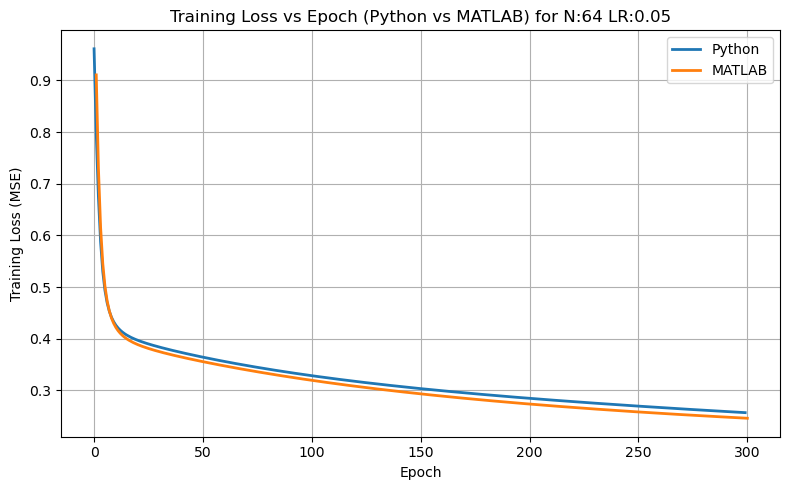

In [24]:
#Now we proceed to create the training curve for Loss vs Epoch

python_df = pd.read_csv("python_epoch_losses.csv")
matlab_df = pd.read_csv("matlab_losses.csv")

plt.figure(figsize=(8,5))

plt.plot(python_df["epoch"], python_df["train_loss"], 
         label="Python", linewidth=2)

plt.plot(matlab_df["Epoch"], matlab_df["Loss"], 
         label="MATLAB", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss vs Epoch (Python vs MATLAB) for N:64 LR:0.05")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("python_vs_matlab_loss_vs_epoch.png", dpi=300)

plt.show()

In [23]:
#Now for the required grid

hidden_list = [32, 64, 128]
learning_rate_list = [0.01, 0.05, 0.1]
epochs=300

results=[]
best=None
best_acc = -1

for h in hidden_list:
    for learning_rate in learning_rate_list:
        print(f"Training: hidden={h}, learning_rate={learning_rate}")
        res = train_one_setting(n_hidden=h, learning_rate=learning_rate, epochs=epochs, record_curve=False)
        results.append(res)
        print(f" time={res['total_time_sec']:.3f}s | acc={res['test_accuracy']:.4f} | final_loss={res['final_train_loss']:.4f}")

        if res["test_accuracy"] > best_acc:
            best_acc = res["test_accuracy"]
            best = (h, learning_rate)

df_res=pd.DataFrame(results).sort_values(["n_hidden", "learning_rate"]).reset_index(drop=True)
display(df_res)

df_res.to_csv("python_grid_results_sigmoid_mse.csv", index=False)
print("Saved: python_grid_results_sigmoid_mse.csv")

Training: hidden=32, learning_rate=0.01
 time=1.968s | acc=34.0801 | final_loss=0.4427
Training: hidden=32, learning_rate=0.05
 time=2.034s | acc=38.1197 | final_loss=0.3699
Training: hidden=32, learning_rate=0.1
 time=1.928s | acc=64.1205 | final_loss=0.3138
Training: hidden=64, learning_rate=0.01
 time=3.515s | acc=35.7326 | final_loss=0.3917
Training: hidden=64, learning_rate=0.05
 time=3.646s | acc=60.1542 | final_loss=0.3232
Training: hidden=64, learning_rate=0.1
 time=3.471s | acc=65.2956 | final_loss=0.2876
Training: hidden=128, learning_rate=0.01
 time=6.424s | acc=28.3878 | final_loss=0.3898
Training: hidden=128, learning_rate=0.05
 time=6.428s | acc=60.9989 | final_loss=0.2999
Training: hidden=128, learning_rate=0.1
 time=6.441s | acc=71.4286 | final_loss=0.2507


,n_hidden,learning_rate,epochs,total_time_sec,test_accuracy,final_train_loss
0,32,0.01,300,1.967653,34.080059,0.442707
1,32,0.05,300,2.034272,38.119721,0.369897
2,32,0.10,300,1.928094,64.120455,0.313787
3,64,0.01,300,3.514607,35.732648,0.391667
4,64,0.05,300,3.646419,60.154242,0.323218
5,64,0.10,300,3.470766,65.295630,0.287557
6,128,0.01,300,6.424056,28.387808,0.389782
7,128,0.05,300,6.427575,60.998898,0.299891
8,128,0.10,300,6.441348,71.428571,0.250749


Saved: python_grid_results_sigmoid_mse.csv


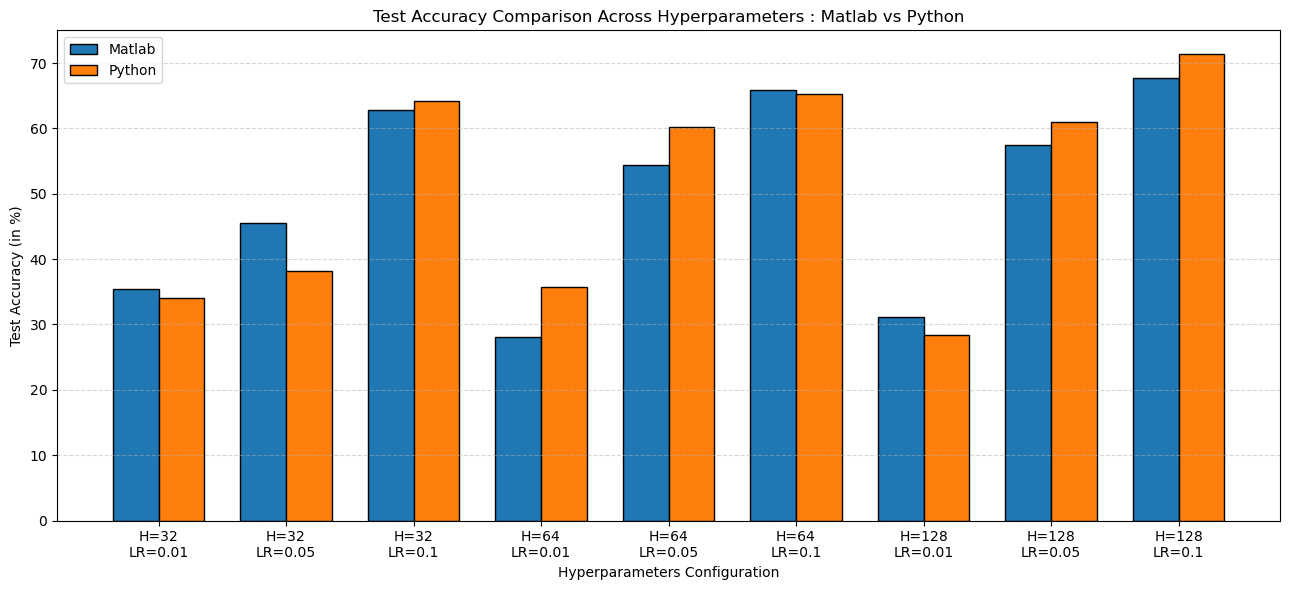

In [29]:
#Now we will create a bar chart for the test accuracy comparison across hyperparameters

py = pd.read_csv("python_grid_results_sigmoid_mse.csv")
mat = pd.read_csv("hyperparameter_results.csv")

#Here we keep only the columns that we need
py = py[["n_hidden","learning_rate","test_accuracy"]].copy()
mat = mat[["HiddenNeurons","LearningRate","Accuracy"]].copy()

#Here we sort the values, so both can align
py = py.sort_values(["n_hidden","learning_rate"]).reset_index(drop=True)
mat = mat.sort_values(["HiddenNeurons","LearningRate"]).reset_index(drop=True)

#Here we make the x-axis labels
labels = [f"H={h}\nLR={lr}" for h, lr in zip(py["n_hidden"], py["learning_rate"])]

python_accuracy = py["test_accuracy"].to_numpy()
matlab_accuracy = mat["Accuracy"].to_numpy()

x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(13,6))

#Here we create the bars
plt.bar(x - width/2, matlab_accuracy, width,
        label="Matlab", edgecolor="black")
plt.bar(x + width/2, python_accuracy, width,
        label="Python", edgecolor="black")

#Here we create the titles
plt.title("Test Accuracy Comparison Across Hyperparameters : Matlab vs Python")
plt.ylabel("Test Accuracy (in %)")
plt.xlabel("Hyperparameters Configuration")
plt.xticks(x, labels)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend()
plt.tight_layout()
plt.savefig("matlab_vs_python_test_accuracy", dpi=300)
plt.show()